In [48]:
import numpy as np # для матричных вычислений
import pandas as pd # для анализа и предобработки данных
import matplotlib.pyplot as plt # для визуализации
import seaborn as sns # для визуализации

from sklearn import linear_model # линейные модели
from sklearn import metrics # метрики
from sklearn import preprocessing # предобработка
from sklearn.model_selection import train_test_split # разделение выборки


Прочитаем данные:

In [49]:
data = pd.read_csv('data/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Итак, набор данных содержит следующие столбцы:

age — возраст страхователя;
sex — пол;
bmi — индекс массы тела (
к
г
м
), в идеале — от 18.5 до 24.9;
children — количество детей, охваченных медицинской страховкой;
smoker — является ли человек курящим;
region — район проживания в США (северо-восток, юго-восток, северо-запад, юго-запад);
charges (целевой признак) — индивидуальные медицинские расходы, оплачиваемые медицинской страховкой.

Размер таблицы:

In [50]:
print(data.shape)
# (1338, 7)

(1338, 7)


Выведем информацию о пропусках, так как наличие пропусков не позволит нам построить модель линейной регрессии:

In [51]:
print(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Пропуски в таблице отсутствуют.

Посмотрим на типы данных:

In [52]:
print(data.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [53]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [54]:
data.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


Наши данные содержат несколько типов признаков:

age, bmi, children — числовые признаки;
sex, smoker — бинарные категориальные переменные (две категории);
region — множественные категориальные переменные (несколько категорий);
charges — числовой целевой признак.


Прежде чем приступать к этапу подготовки данных для модели, вы можете произвести небольшое исследование зависимостей в данных, например построить следующие графики и диаграммы:

гистограммы/коробчатые диаграммы числовых признаков;
столбчатые диаграммы медианных медицинских расходов в зависимости от категориальных признаков;
диаграммы рассеяния зависимости целевого признака от других числовых в разрезе категориальных (обратите особенное внимание на зависимость медицинских расходов от признака курения).

In [55]:
# make a copy
temp_data = data.copy()

In [56]:
# выделим числовые признаки
types = temp_data.dtypes
num_features = list(types[(types != 'object')].index) #temp_data.select_dtypes(include='number').index
print(num_features)

['age', 'bmi', 'children', 'charges']


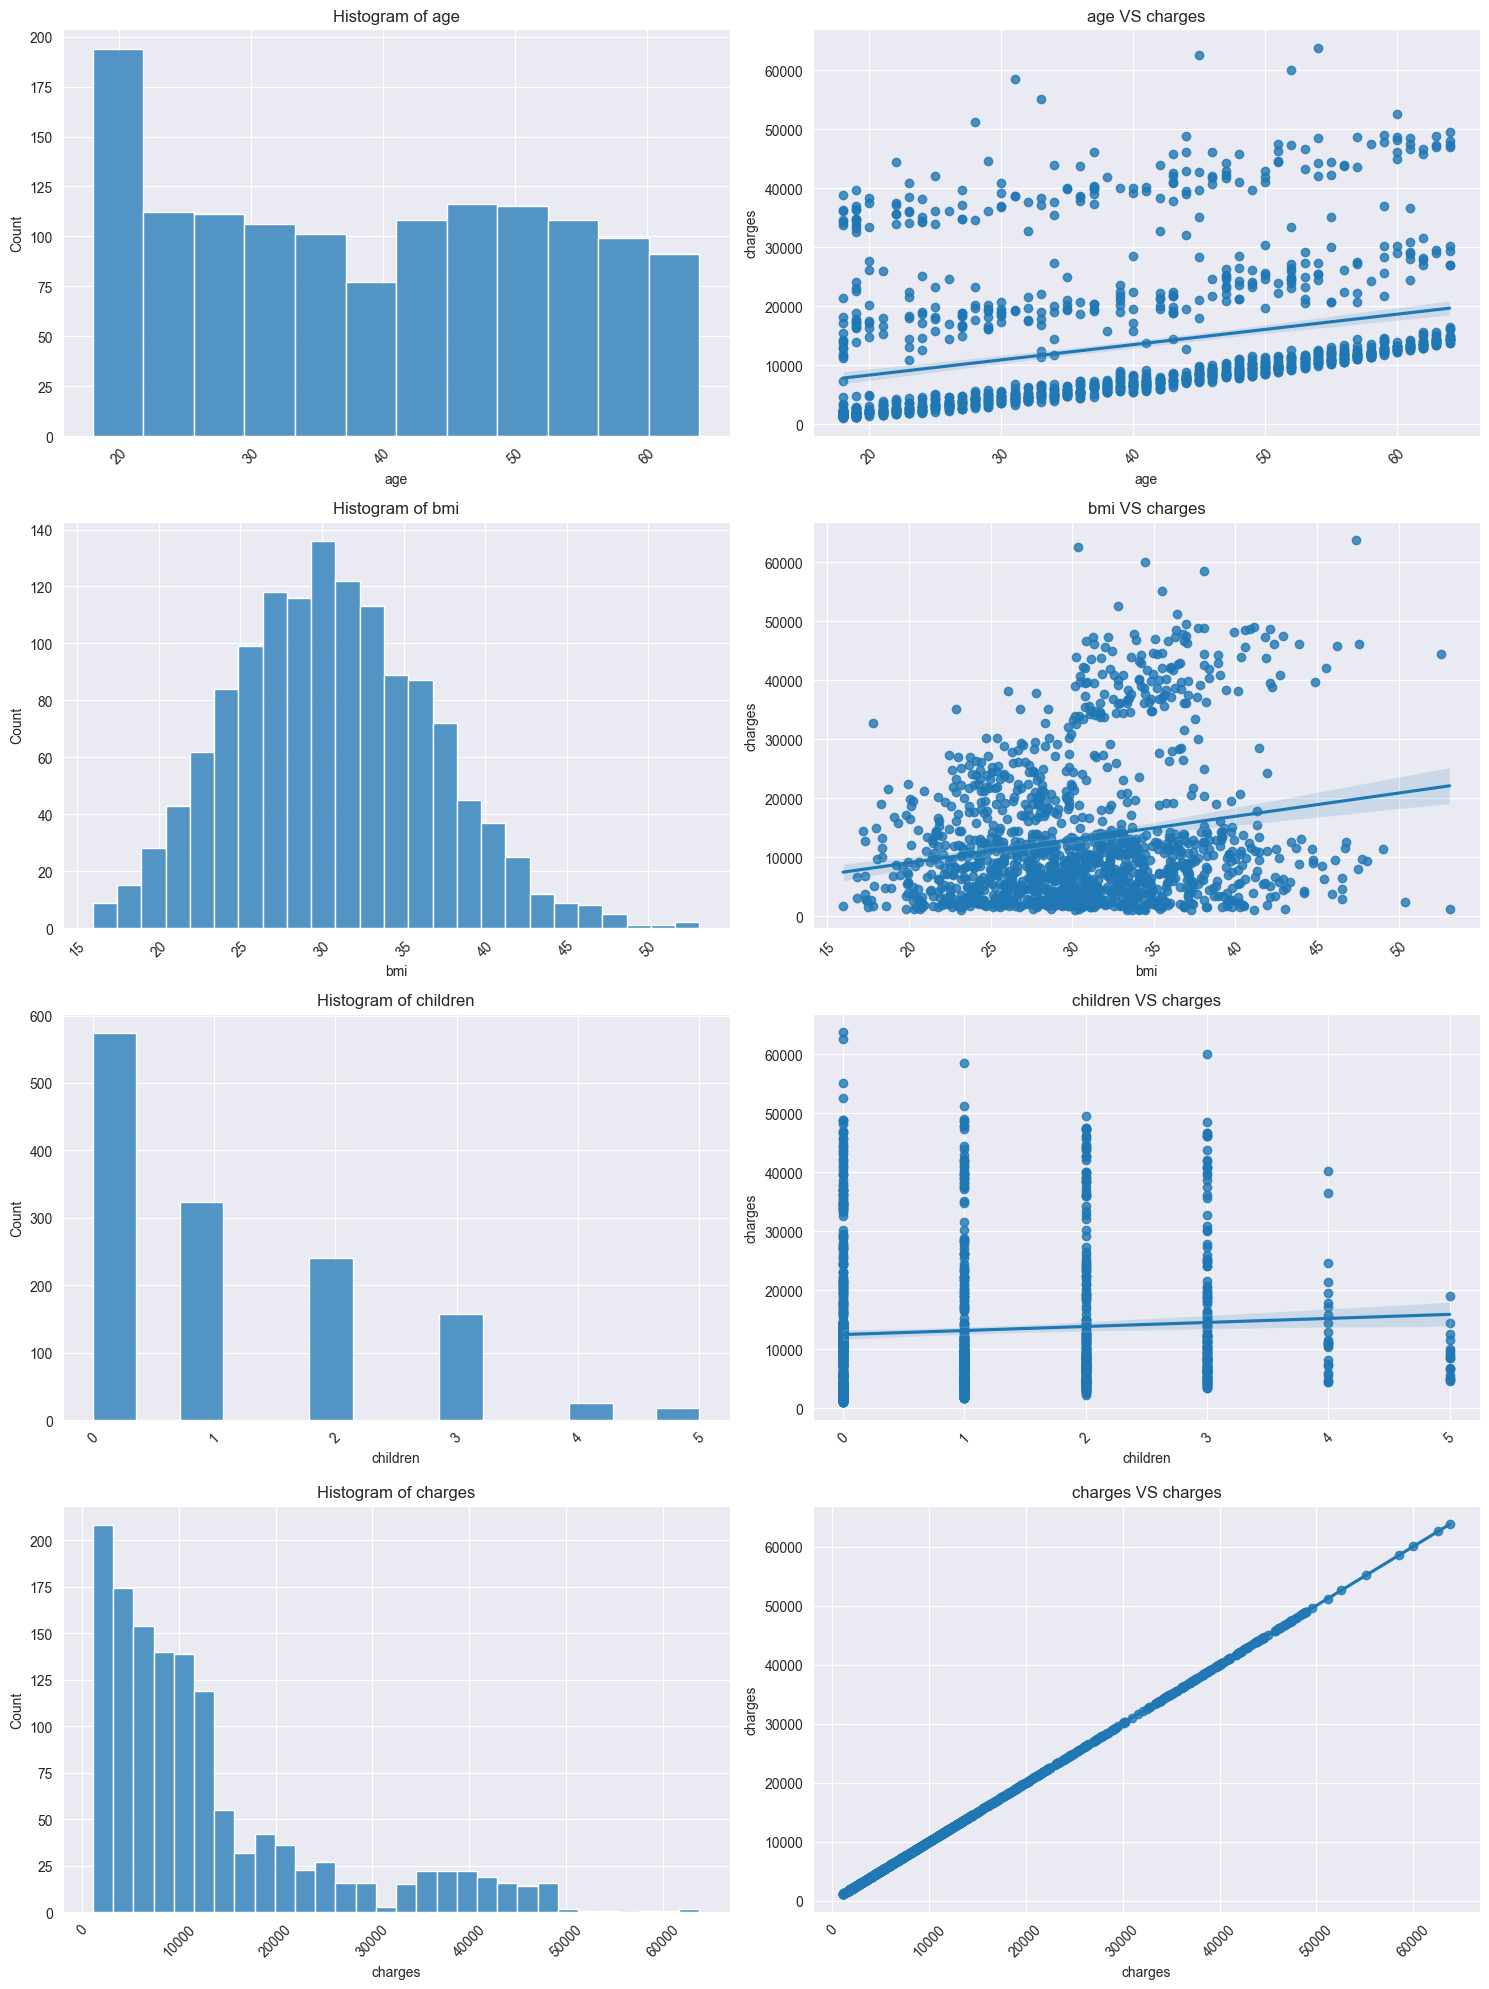

In [57]:
n = len(num_features)
fig, ax = plt.subplots(n, 2, figsize=(15, 20))

for i, feature in enumerate(num_features):
    hist_plot = sns.histplot(data=temp_data, x=feature, ax=ax[i][0])
    hist_plot.set_title(f'Histogram of {feature}')
    hist_plot.xaxis.set_tick_params(rotation=45)
    reg_plot = sns.regplot(data=temp_data, x=feature, y='charges', ax=ax[i][1])
    reg_plot.set_title(f'{feature} VS charges')
    reg_plot.xaxis.set_tick_params(rotation=45)
plt.tight_layout()

<Axes: >

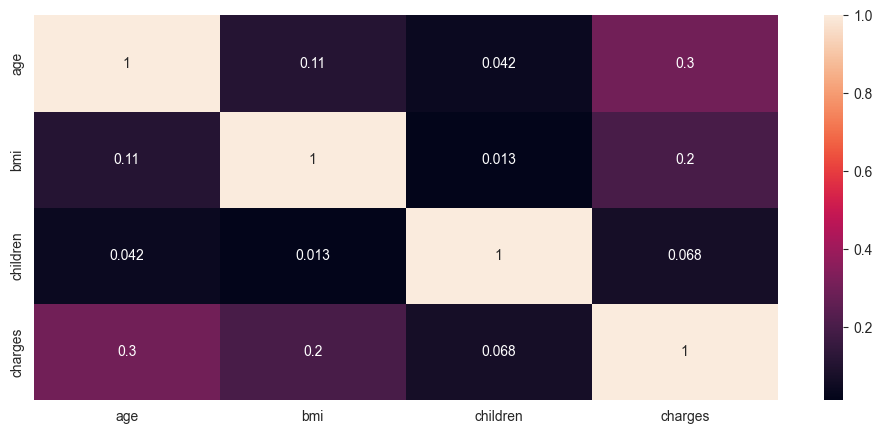

In [63]:
# построим тепловую карту
temp_data_num = temp_data.drop(columns=['sex', 'smoker', 'region'])
fig = plt.figure(figsize=(12, 5))
sns.heatmap(temp_data_num.corr(), annot=True)

### ПОДГОТОВКА ДАННЫХ

In [66]:
# кодируем бинарные категориальные признаки
temp_data['smoker'] = temp_data['smoker'].apply(lambda x: 0 if x == 'no' else 1)
temp_data['sex'] = temp_data['sex'].apply(lambda x: 0 if x == 'female' else 1)
# оставшиеся категориальные признаки кодируем с помощью OneHot
temp_data = pd.get_dummies(data)
temp_data.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [84]:
# X = temp_data.drop('charges', axis=1)
# y = temp_data['charges']

features = temp_data.drop('charges', axis=1).columns
X, y = temp_data[features], temp_data['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1070, 11)
(268, 11)


In [82]:
# функция, считающая метрики
def print_metrics(y_train, y_train_pred, y_test, y_test_pred):
    print(f'Train R^2: {metrics.r2_score(y_train, y_train_pred):.3f}')
    print(f'Train MAE: {metrics.mean_absolute_error(y_train, y_train_pred):.3f}')
    print(f'Train MAPE: {metrics.mean_absolute_percentage_error(y_train, y_train_pred)*100:.3f}')
    print('\n')
    print(f'Test R^2: {metrics.r2_score(y_test, y_test_pred):.3f}')
    print(f'Test MAE: {metrics.mean_absolute_error(y_test, y_test_pred):.3f}')
    print(f'Test MAPE: {metrics.mean_absolute_percentage_error(y_test, y_test_pred)*100:.3f}')

In [85]:
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Train R^2: 0.742
Train MAE: 4208.235
Train MAPE: 42.203


Test R^2: 0.784
Test MAE: 4181.194
Test MAPE: 46.888


In [86]:
print(f'w0: {lr.intercept_}') # свободный член w0
print(f'w1: {lr.coef_}') # остальные параметры модели w1, w2, ..., wm

w0: -574.5357125102091
w1: [ 2.56975706e+02  3.37092552e+02  4.25278784e+02  9.29584582e+00
 -9.29584582e+00 -1.18255644e+04  1.18255644e+04  4.59585244e+02
  8.89079180e+01 -1.98279052e+02 -3.50214110e+02]


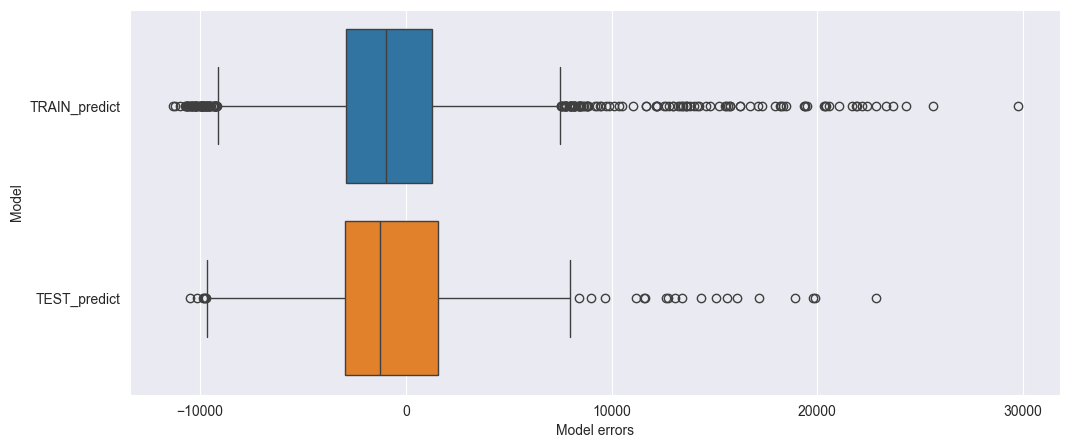

In [88]:
#Визуализируем ошибки
fig, ax = plt.subplots(figsize=(12, 5))

#Ошибки модели на тренировочных данных
y_errors_train = y_train - y_train_pred
#Ошибки модели на тестовых данных
y_errors_test = y_test - y_test_pred
#Для удобства визуализации составим DataFrame из ошибок
errors_df = pd.DataFrame(
    {'TRAIN_predict': y_errors_train,
     'TEST_predict': y_errors_test
    }
)
#Строим boxplot для ошибок
sns.boxplot(data=errors_df, orient='h', ax=ax)
ax.set_xlabel('Model errors') # название оси абсцисс
ax.set_ylabel('Model'); # название оси ординат

In [89]:
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train_scaled)
X_train_scaled_poly = poly.transform(X_train_scaled)
X_test_scaled_poly = poly.transform(X_test_scaled)

print(X_train_scaled_poly.shape)
print(X_test_scaled_poly.shape)

(1070, 77)
(268, 77)


In [90]:
lr_poly = linear_model.LinearRegression()
lr_poly.fit(X_train_scaled_poly, y_train)
y_train_pred = lr_poly.predict(X_train_scaled_poly)
y_test_pred = lr_poly.predict(X_test_scaled_poly)
print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Train R^2: 0.842
Train MAE: 2892.150
Train MAPE: 29.399


Test R^2: 0.867
Test MAE: 2729.500
Test MAPE: 30.199


In [92]:
# print(f'w0: {lr_poly.intercept_}') # свободный член w0
print(f'w1: {lr_poly.coef_}') # остальные параметры модели w1, w2, ..., wm

w1: [ 1.80185451e+03  1.56281092e+04  1.80411808e+03  1.47294920e+02
 -1.47294920e+02 -4.89409895e+02  4.89409895e+02  9.64775643e+01
 -2.72234140e+02  1.13685400e+02  6.20711754e+01  8.39963609e+03
  9.95686519e+02 -1.66691118e+03  4.94694463e+02  1.30716005e+03
  8.14675740e+02  9.87178771e+02 -1.10989656e+03  1.89692150e+01
  1.19404894e+03  1.69873292e+03 -9.71100034e+03  1.55987212e+03
  7.49031724e+03  8.13779199e+03 -1.96055517e+04  3.52336609e+04
  6.20506146e+03  5.18890764e+03  1.62832077e+03  2.60581936e+03
 -2.09061757e+03  1.52115810e+03  2.82959981e+02  2.01880110e+03
 -2.14683018e+02  1.73007107e+03  1.75566558e+03 -2.97738778e+02
 -1.38387979e+03  1.47294920e+02  0.00000000e+00 -1.06723124e+02
  2.54018044e+02  5.16246876e+02 -3.07359994e+02 -2.30595947e+02
  1.69003984e+02 -1.47294920e+02 -3.82686771e+02  2.35391851e+02
 -4.19769312e+02  3.51258545e+01  3.44281347e+02 -1.06932809e+02
 -4.89409895e+02  0.00000000e+00 -9.10008270e+01  3.33282629e+01
  3.71874856e+02 -8.0

In [93]:
lasso_lr_poly = linear_model.Lasso(max_iter=2000)
lasso_lr_poly.fit(X_train_scaled_poly, y_train)
y_train_pred = lasso_lr_poly.predict(X_train_scaled_poly)
y_test_pred = lasso_lr_poly.predict(X_test_scaled_poly)
print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Train R^2: 0.842
Train MAE: 2890.010
Train MAPE: 29.371


Test R^2: 0.867
Test MAE: 2718.132
Test MAPE: 30.031


In [94]:
ridge_lr_poly = linear_model.Ridge()
ridge_lr_poly.fit(X_train_scaled_poly, y_train)
y_train_pred = ridge_lr_poly.predict(X_train_scaled_poly)
y_test_pred = ridge_lr_poly.predict(X_test_scaled_poly)
print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Train R^2: 0.840
Train MAE: 2923.465
Train MAPE: 29.065


Test R^2: 0.865
Test MAE: 2795.575
Test MAPE: 30.211
